# Rock-vapour atmospheres versus melt FeO and temperature

This notebook computes the surface composition of the vapour over a magma ocean, over a grid of melt FeO contents and melt temperatures $T_\mathrm{magma}$. 

It uses **LavAtmos** (Van Buchem et al. 2023, [arXiv:2210.10463](https://arxiv.org/abs/2210.10463)), which combines MELTS melt activities with FastChem gas speciation. The oxygen fugacity is **solved for**, not imposed. It is then expressed as ΔIW with CALLIOPE's O'Neill & Eggins (2002) iron–wüstite buffer. AGNI is not called; the exported table is the input for the climate notebook.

In [1]:
import os, sys, time, contextlib
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from calliope.oxygen_fugacity import OxygenFugacity

# Set paths
AGNI_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))   # notebook lives in misc/science/
LAVA_DIR = os.path.join(AGNI_DIR, "LavAtmos")
FC_DIR   = os.path.join(AGNI_DIR, "fastchem")
OUT_DIR  = os.path.join(AGNI_DIR, "out", "feo_congruent")
BASE_MELT = os.path.join(LAVA_DIR, "input", "lava_compositions", "BSE_palm.csv")

In [2]:

os.environ["LAVA_DIR"], os.environ["FC_DIR"] = LAVA_DIR, FC_DIR
sys.path.insert(0, LAVA_DIR)
import lavatmos3


FC_TEMPLATE = os.path.join(LAVA_DIR, "input", "fastchem3", "config_template.input")
print(os.path.isfile(FC_TEMPLATE))

True


In [3]:

# volatile content and pressure at which activities are calculated [bar]
P_VOL, P_MELT = 1e-8, 0.01           

# number ratios of elements in background atmosphere
VOLATILES = {"O": 1.0, "H": 1e-9, "C": 0.0, "N": 0.0, "S": 0.0, "P": 0.0}  

# FeO wt% grid
FEO_WT = 10 ** np.arange(-3.5, 2.5, 1.5)           
print(FEO_WT)

# Temperature grid 
T_MAGMA = [2000.0, 2500.0, 3000.0] 

# Number of processes to parallelise
N_PROC = 10

# Construct cases
CASES = [(float(w), T) for w in FEO_WT for T in T_MAGMA]
print(f"{len(CASES)} cases on {N_PROC} processes")

[3.16227766e-04 1.00000000e-02 3.16227766e-01 1.00000000e+01]
12 cases on 10 processes


## Melt compositions and the LavAtmos call
LavAtmos is given an oxygen-only volatile inventory of negligible pressure (`P_VOL` = 10$^{-8}$ bar). This forces FastChem's $p_\mathrm{O_2}$ to equal the solved fO$_2$, rather than trying to equilibriate with an existing atmosphere.

In [4]:

# MMW of refractory species (g/mol)
OXIDE_MM = {"SiO2": 60.084, "MgO": 40.304, "Al2O3": 101.961, "TiO2": 79.866, "FeO": 71.844, "CaO": 56.077, "Na2O": 61.979, "K2O": 94.196}   # [g mol-1]

# Baseline melt composition (BSE)
base_melt = {str(k): float(v) for k, v in pd.read_csv(BASE_MELT, header=None).values}
FEO_BSE = base_melt["FeO"]

# Function to set FeO to feo_wt [wt%] and rescale the other oxides so that the total is unchanged
def melt_with_feo(feo_wt):

    # not FeO
    others = {k: v for k, v in base_melt.items() if k != "FeO"}
    scale = (sum(base_melt.values()) - feo_wt) / sum(others.values()) # scale factor

    # return updated dict of melt compositions
    return {**{k: v * scale for k, v in others.items()}, "FeO": feo_wt}


# object for lavatmos
class LavaPaths:
    # The paths object LavAtmos expects, following paths_importer in PROTEUS (src/proteus/outgas/lavatmos.py)
    def __init__(self, out):
        self.lavatmos_dir, self.fastchem3_dir = LAVA_DIR + "/", FC_DIR + "/"
        self.input_dir = os.path.join(LAVA_DIR, "input") + "/"
        self.fastchem3_config_template = FC_TEMPLATE
        self.element_abundance_template = os.path.join(self.input_dir, "fastchem3", "element_abundances",
                                                       "element_abundances_template2.dat")
        self.species_data_file      = os.path.join(FC_DIR, "input", "logK", "logK.dat")
        self.species_data_file_cond = os.path.join(FC_DIR, "input", "logK", "logK_condensates.dat")
        for d in ("element_abundances", "fastchem"):
            os.makedirs(os.path.join(out, d), exist_ok=True)
        self.element_abundance_output = os.path.join(out, "element_abundances", "element_abundances_output.dat")
        self.fastchem3_output = self.output_dir = os.path.join(out, "fastchem", "")
        self.janafdata = os.path.join(LAVA_DIR, "data")

@contextlib.contextmanager
def in_dir(path):
    # LavAtmos resolves some data paths relative to the working directory
    old = os.getcwd(); os.chdir(path)
    try:
        yield
    finally:
        os.chdir(old)

# function to run vaporisation for (FeO wt%, T); returns FastChem partial pressures [bar] plus diagnostics
def vaporise_case(case):

    # print FeO wt% and temperature
    w, T = case
    tag = f"FeO={w:08.5f}_T={T:04.0f}"
    print("Calculating case: "+tag + "\n")

    # do calculation
    work = os.path.join(OUT_DIR, "work", tag)
    system = lavatmos3.melt_vapor_system(LavaPaths(work))
    with in_dir(LAVA_DIR):
        pp = system.vaporise(T, P_VOL, melt_with_feo(w), VOLATILES, P_melt=P_MELT, verbose=False).iloc[0]
        vap = system.vapor_partial_pressure_calc(pp["O2"], np.array([T])).iloc[0]   # melt equilibrium at returned fO2

    # get result from fastchem to check pO2 vs fO2
    p_feo_melt = sum(vap.iloc[i] for i, n in enumerate(system.cdef.index) if n == "FeO(g)")
    with open(os.path.join(work, "fastchem", "monitor.dat")) as f:
        mon = f.read().split("\n")[1].split()

    # construct result as dataframe
    out = pd.concat([pp, pd.Series({"FeO_consistency": pp["Fe1O1"] / p_feo_melt,
                                    "fc_converged": float(mon[4] == "ok" and mon[5] == "ok")})])

    # save and return
    out.to_csv(os.path.join(OUT_DIR,tag+".csv"))
    print("    Done with case: "+tag+ "\n")
    return case, out

## Sweep

Cases run in parallel. Each takes about a minute.

In [5]:
t0 = time.time()
with ProcessPoolExecutor(N_PROC, mp_context=mp.get_context("fork")) as ex:
    raw = dict(ex.map(vaporise_case, CASES))
print(f"wall time {(time.time() - t0) / 60:.1f} min")

/home/harrison/miniforge3/envs/prt/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=190642) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


Calculating case: FeO00.0003_T2000
Calculating case: FeO00.0003_T3000
Calculating case: FeO00.0100_T2000
Calculating case: FeO00.0100_T3000
Calculating case: FeO00.3162_T2500
Calculating case: FeO10.0000_T2000
Calculating case: FeO00.0100_T2500
Calculating case: FeO00.3162_T2000


Calculating case: FeO00.0003_T2500





Calculating case: FeO00.3162_T3000





Calculated composition is infeasible!
Calculated composition is infeasible!
Calculated composition is infeasible!
Calculated composition is infeasible!
Calculated composition is infeasible!
Calculated composition is infeasible!
Calculated composition is infeasible!
Calculated composition is infeasible!
Calculated composition is infeasible!


    Done with case: FeO00.3162_T2000

Calculating case: FeO10.0000_T2500

    Done with case: FeO10.0000_T2000

Calculating case: FeO10.0000_T3000

    Done with case: FeO00.0003_T2000

    Done with case: FeO00.0100_T2000

    Done with case: FeO00.0100_T3000

    Done with case: FeO00.3162_T3000

    Done with case: FeO00.0003_T2500

    Done with case: FeO00.0100_T2500

    Done with case: FeO00.0003_T3000

    Done with case: FeO10.0000_T2500

    Done with case: FeO00.3162_T2500

    Done with case: FeO10.0000_T3000

wall time 1.7 min


## Composition table and checks

Ions and electrons are dropped; they make up less than 10$^{-4}$ of the pressure. $P_\mathrm{surf}$ is the sum of the neutral partial pressures. The checks are:

* the final FastChem call converged;
* FastChem's $p_\mathrm{FeO}$ matches the melt equilibrium to within 1%;
* ΔIW is finite;
* $p_\mathrm{FeO}$ increases with melt FeO at every temperature.

For reference, a wrong fO$_2$ fed to the melt equilibrium shifts `FeO_consistency` by factors of several.

In [6]:
# iron wustite buffer
iw = OxygenFugacity(model="oneill")
rows = []

# loop through grid
for (w, T), s in raw.items():
    # drop ions
    neutral = s[[k for k in s.index if not k.endswith(("+", "-")) and k not in ("FeO_consistency", "fc_converged")]]
    neutral = neutral[neutral > 0]
    P = neutral.sum()

    # store extra keys in row for this grid point
    rows.append(dict(FeO_wt=w, T_magma=T, P_surf_bar=P, dIW=np.log10(neutral["O2"]) - iw(T),
                     FeO_consistency=s["FeO_consistency"], fc_converged=bool(s["fc_converged"]),
                     **{"x_" + k: v / P for k, v in neutral.items()}))

# replace NaN with zero
tab = pd.DataFrame(rows).set_index(["FeO_wt", "T_magma"]).sort_index().fillna(0.0)

# show which cases failed
checks = {"fastchem_converged": tab.fc_converged.all(),
          "melt_gas_consistent": bool(np.all(np.abs(tab.FeO_consistency - 1) < 0.01)),
          "dIW_finite": bool(np.all(np.isfinite(tab.dIW))),
          "pFeO_increases_with_FeO": all(np.all(np.diff((g.x_Fe1O1 * g.P_surf_bar).values) > 0)
                                         for _, g in tab.groupby(level="T_magma"))}
print(checks)
tab[["P_surf_bar", "dIW", "x_Fe1O1", "x_Fe", "x_O2", "x_Na", "x_O1Si1", "FeO_consistency"]].unstack("T_magma")["x_Fe1O1"]

{'fastchem_converged': np.True_, 'melt_gas_consistent': True, 'dIW_finite': True, 'pFeO_increases_with_FeO': True}


T_magma,2000.0,2500.0,3000.0
FeO_wt,,,
0.000316,0.000026,0.000090,0.000108
0.010000,0.000146,0.000507,0.000607
0.316228,0.000820,0.002829,0.003403
10.000000,0.004501,0.016024,0.021756


## FeO VMR, surface pressure and ΔIW

Each line is one $T_\mathrm{magma}$ (blue ramp, light to dark for cool to hot). The dashed vertical line marks BSE FeO.

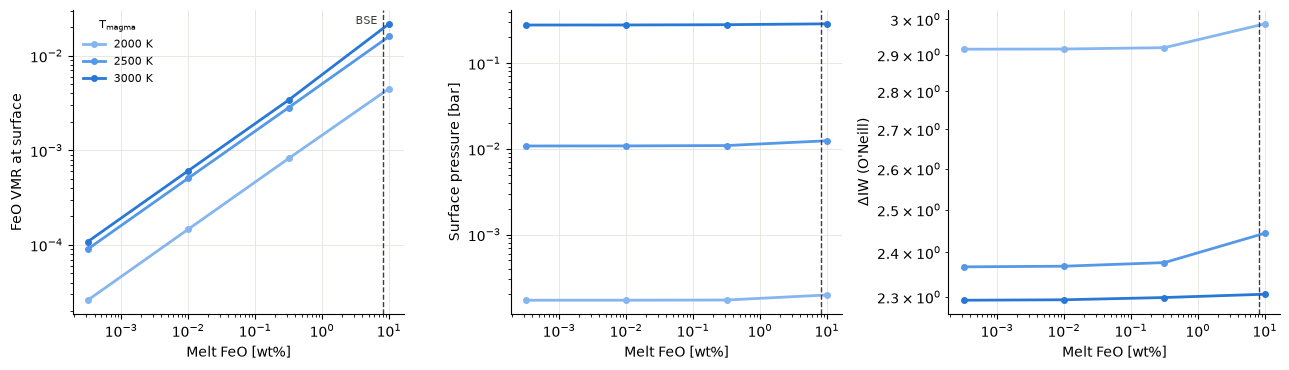

In [7]:

# colours for plot
T_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]    # ordinal blue, cool -> hot
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e4e3dd", "grid.linewidth": 0.6, "lines.linewidth": 2})

# make plot
fig, axs = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)

# for each temperature
for T, c in zip(T_MAGMA, T_RAMP):
    g = tab.xs(T, level="T_magma")

    # vmr of FeO in atmosphere
    axs[0].plot(g.index, g.x_Fe1O1, color=c, marker="o", ms=4, label=f"{T:.0f} K")

    # total surface pressure
    axs[1].plot(g.index, g.P_surf_bar, color=c, marker="o", ms=4)

    # Delta IW
    axs[2].plot(g.index, g.dIW, color=c, marker="o", ms=4)

# add line showing BSE, and decorate
for ax, lab in zip(axs, ["FeO VMR at surface", "Surface pressure [bar]", "ΔIW (O'Neill)"]):
    ax.axvline(FEO_BSE, color="#3d3d3a", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("Melt FeO [wt%]")
    ax.set_ylabel(lab)
    ax.set_yscale("log")

# annotate BSE label
axs[0].annotate("BSE", (FEO_BSE, 1), xycoords=("data", "axes fraction"), xytext=(-4, -4),
                textcoords="offset points", ha="right", va="top", fontsize=8, color="#3d3d3a")

# add legend
axs[0].legend(frameon=False, fontsize=8, title="T$_\\mathrm{magma}$", title_fontsize=8)

# save
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "feo_vmr_psurf_dIW.pdf"), bbox_inches="tight")
plt.show()

## Export for AGNI

`compositions_agni.csv` holds, for each (FeO, $T_\mathrm{magma}$):

* `P_surf_bar` and `dIW`;
* VMRs for gases with an AGNI thermodynamics file, renamed to AGNI names and renormalised to 1. The unmapped pressure fraction is recorded in `frac_unmapped`.

In [9]:
# species to store (converted from FC name to AGNI name)
FC_TO_AGNI = {"Na": "Na", "K": "K", "Fe": "Fe", "Mg": "Mg", "Si": "Si", "Ca": "Ca", "Al": "Al", "Ti": "Ti",
              "O": "O", "O2": "O2", "Fe1O1": "FeO", "O1Si1": "SiO", "O2Si1": "SiO2", "Mg1O1": "MgO",
              "O1Ti1": "TiO", "O2Ti1": "TiO2", "Ca1O1": "CaO", "Al1O1": "AlO", "Na1O1": "NaO", "Mg2": "Mg2", "Na2": "Na2"}

# make dataframe with VMRs
vmr = pd.DataFrame({g: tab["x_" + fc] for fc, g in FC_TO_AGNI.items() if "x_" + fc in tab})

# add other keys to total dataframe
agni = tab[["P_surf_bar", "dIW"]].copy() 
agni["frac_unmapped"] = 1 - vmr.sum(axis=1)
agni = agni.join((vmr.div(vmr.sum(axis=1), axis=0)).add_prefix("vmr_"))

# save to csv 
agni.to_csv(os.path.join(OUT_DIR, "compositions_agni.csv"))
print(f"max unmapped fraction {agni.frac_unmapped.max():.1e}; wrote {OUT_DIR}/compositions_agni.csv")

max unmapped fraction 5.2e-04; wrote /home/harrison/Projects/AGNI/out/feo_congruent/compositions_agni.csv
